In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch, welch


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/sleep_apnea/B_DataSet.csv')

In [ ]:
data.head()

,Record_ID,Segment_ID,Signal_Data,Label
0,b01,1,"['-0.0007500', '-0.0009250', '-0.0007750', '-0...",N
1,b01,2,"['-0.0002250', '-0.0001500', '-0.0010500', '-0...",N
2,b01,3,"['0.0089000', '0.0017750', '-0.0008250', '-0.0...",N
3,b01,4,"['-0.0000250', '-0.0002000', '-0.0003000', '-0...",N
4,b01,5,"['-0.0002750', '-0.0003500', '-0.0003500', '-0...",N


In [ ]:
from scipy.signal import butter, filtfilt, iirnotch, savgol_filter

def highpass_filter(signal, fs, cutoff=0.5, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, signal)

def notch_filter(signal, fs, f0=50, Q=30):
    b, a = iirnotch(f0, Q, fs)
    return filtfilt(b, a, signal)

In [ ]:
preprocessed_segments = []

In [ ]:
for i in data['Signal_Data']:
  x = i.strip('[]\n').split()
  t= []
  for j in x:
    # Remove commas and any other non-numeric characters before converting to float
    cleaned_j = j.replace(',', '').replace("'", "")  # Replace comma and apostrophe
    try:
        t.append(float(cleaned_j))
    except ValueError:
        print(f"Could not convert '{cleaned_j}' to float")  # Print error message for debugging
  x = highpass_filter(t, 100)
  preprocessed_segments.append(notch_filter(x, 100).tolist())

In [ ]:
!pip install neurokit2

In [ ]:
import neurokit2
def detect_r_peaks_sleepecg(segment, fs):
    _, results = neurokit2.ecg_peaks(segment, sampling_rate=fs)
    return results["ECG_R_Peaks"]

In [ ]:
import numpy as np
def compute_rr_intervals(r_peaks, fs):
    rr_intervals = np.diff(r_peaks) / fs
    return rr_intervals

In [ ]:
def compute_mean_rr(rr_intervals):
    """Compute the Mean RR interval."""
    return np.mean(rr_intervals) if len(rr_intervals) > 0 else None
def compute_sd_rr(rr_intervals):
    """Compute the Standard Deviation of RR Intervals."""
    return np.std(rr_intervals, ddof=1) if len(rr_intervals) > 1 else None
def compute_rmssd(rr_intervals):
    """Compute RMSSD: Root mean square of successive RR differences."""
    return np.sqrt(np.mean(np.diff(rr_intervals) ** 2)) if len(rr_intervals) > 1 else None
def compute_nn50(rr_intervals):
    """Count the number of successive RR intervals differing by more than 50ms."""
    return np.sum(np.abs(np.diff(rr_intervals)) > 0.05) if len(rr_intervals) > 1 else 0
def compute_pnn50(rr_intervals):
    """Compute the percentage of NN50 (NN50 divided by total RR intervals)."""
    return (compute_nn50(rr_intervals) / len(rr_intervals)) * 100 if len(rr_intervals) > 1 else 0


In [ ]:
def compute_avg_heart_rate(rr_intervals):
    """Compute the Average Heart Rate from RR intervals."""
    return np.mean(60 / rr_intervals) if len(rr_intervals) > 0 else None
def compute_std_heart_rate(rr_intervals):
    """Compute the Standard Deviation of Heart Rate (BPM)."""
    return np.std(60 / rr_intervals, ddof=1) if len(rr_intervals) > 0 else None
def compute_avg_hrv(rr_intervals):
    """Compute HRV using RMSSD."""
    return compute_rmssd(rr_intervals)



In [ ]:
def calculate_baseline(segment):
    """Compute the median baseline of an ECG segment."""
    return np.median(segment)
def compute_corrected_amplitudes(r_peaks, segment, baseline):
    """Compute corrected R-peak amplitudes relative to baseline."""
    return [segment[r] - baseline for r in r_peaks] if len(r_peaks) > 0 else []

In [ ]:
def find_p_peak(r_peak, segment, search_window=50):
    """Find the closest local minimum before the R-peak (P-wave approximation)."""
    start = max(0, r_peak - search_window)
    return start + np.argmin(segment[start:r_peak])

def find_t_peak(r_peak, segment, search_window=50):
    """Find the closest local maximum after the R-peak (T-wave approximation)."""
    end = min(len(segment), r_peak + search_window)
    return r_peak + np.argmax(segment[r_peak:end])


In [ ]:
def compute_p_t_amplitudes(r_peaks, segment, baseline):
    """Compute amplitudes of P and T waves relative to baseline."""
    p_amplitudes = []
    t_amplitudes = []

    for r_peak in r_peaks:
        p_peak_index = find_p_peak(r_peak, segment)
        p_amplitudes.append(segment[p_peak_index] - baseline)

        t_peak_index = find_t_peak(r_peak, segment)
        t_amplitudes.append(segment[t_peak_index] - baseline)

    return p_amplitudes, t_amplitudes


In [ ]:
def find_qrs_boundaries(r_peak, segment, fs, pre_window=10, post_window=10):
    """Determine the start and end of the QRS complex."""
    start_search = max(0, r_peak - pre_window)
    end_search = min(len(segment), r_peak + post_window)

    start_idx = start_search + np.argmin(np.diff(segment[start_search:r_peak]))
    end_idx = r_peak + np.argmin(np.diff(segment[r_peak:end_search]))

    return start_idx, end_idx


In [ ]:
def compute_qrs_features(r_peaks, segment, fs):
    """Compute QRS duration, amplitude, and slope."""
    qrs_features = []
    for r_peak in r_peaks:
        start, end = find_qrs_boundaries(r_peak, segment, fs)
        if start < end:
            qrs_duration = (end - start) / fs
            qrs_amplitude = segment[end] - segment[start]
            qrs_slope = qrs_amplitude / qrs_duration
        else:
            qrs_duration, qrs_amplitude, qrs_slope = None, None, None

        qrs_features.append({
            "QRS_Duration": qrs_duration,
            "QRS_Amplitude": qrs_amplitude,
            "QRS_Slope": qrs_slope
        })
    return qrs_features


In [ ]:
def compute_frequency_features(segment, fs, lf_band=(0.04, 0.15), hf_band=(0.15, 0.4)):
    """Compute LF/HF Ratio and Power Spectral Entropy (PSE)."""
    f, psd = welch(segment, fs=fs, nperseg=1024)
    total_power = np.sum(psd)

    psd_normalized = psd / total_power if total_power > 0 else np.zeros_like(psd)

    lf_power = np.sum(psd[np.logical_and(f >= lf_band[0], f <= lf_band[1])])
    hf_power = np.sum(psd[np.logical_and(f >= hf_band[0], f <= hf_band[1])])

    lf_hf_ratio = lf_power / hf_power if hf_power > 0 else None

    pse = -np.sum(psd_normalized * np.log2(psd_normalized, where=psd_normalized > 0))

    return lf_hf_ratio, pse


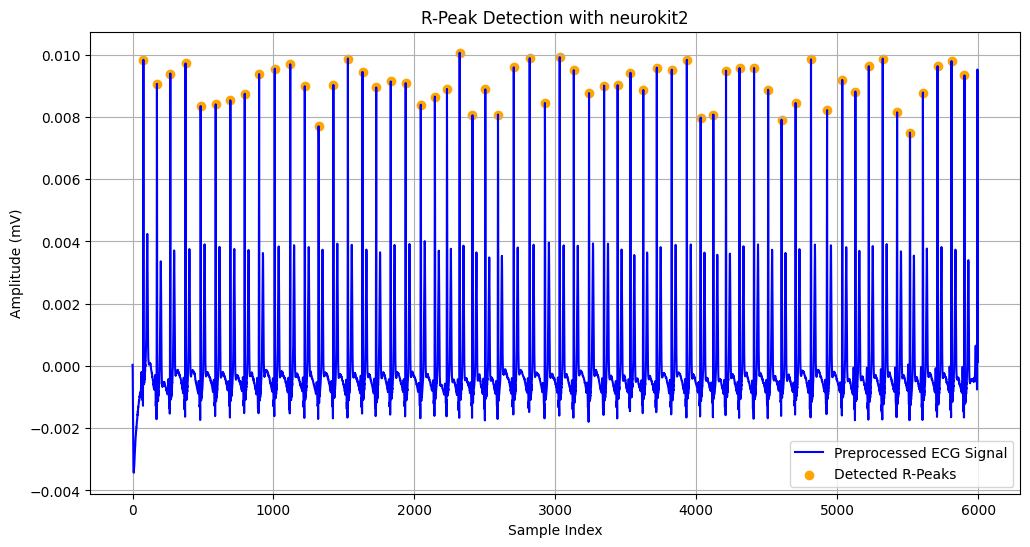

In [ ]:
import matplotlib.pyplot as plt

test_segment = preprocessed_segments[12]
r_peaks = r_peaks_all_segments[12]

plt.figure(figsize=(12, 6))
plt.plot(test_segment, label="Preprocessed ECG Signal", color='blue')
plt.scatter(r_peaks, [test_segment[i] for i in r_peaks], color='orange', label="Detected R-Peaks")
plt.title("R-Peak Detection with neurokit2")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
all_features = []
r_peaks_all_segments = []  # Store R-peaks for all segments


for segment in preprocessed_segments:
    r_peaks = detect_r_peaks_sleepecg(segment, 100)
    r_peaks_all_segments.append(r_peaks)
    rr_intervals = compute_rr_intervals(r_peaks, 100)
    if len(r_peaks) < 2:  # Need at least two R-peaks for RR intervals
      rr_intervals = []
      mean_rr, sd_rr, rmssd, nn50, pnn50, avg_hr, std_hr = [None] * 7
    else:
      rr_intervals = compute_rr_intervals(r_peaks, 100)
      mean_rr = compute_mean_rr(rr_intervals)
      sd_rr = compute_sd_rr(rr_intervals)
      rmssd = compute_rmssd(rr_intervals)
      nn50 = compute_nn50(rr_intervals)
      pnn50 = compute_pnn50(rr_intervals)
      avg_hr = compute_avg_heart_rate(rr_intervals)
      std_hr = compute_std_heart_rate(rr_intervals)

      # Compute all features
      mean_rr = compute_mean_rr(rr_intervals)
      sd_rr = compute_sd_rr(rr_intervals)
      rmssd = compute_rmssd(rr_intervals)
      nn50 = compute_nn50(rr_intervals)
      pnn50 = compute_pnn50(rr_intervals)
      avg_hr = compute_avg_heart_rate(rr_intervals)
      std_hr = compute_std_heart_rate(rr_intervals)

      baseline = calculate_baseline(segment)
      mean_r_amplitude = np.mean(compute_corrected_amplitudes(r_peaks, segment, baseline))

      # QRS Features
      qrs_features = compute_qrs_features(r_peaks, segment, 100)
      mean_qrs_duration = np.mean([f["QRS_Duration"] for f in qrs_features if f["QRS_Duration"] is not None])
      mean_qrs_amplitude = np.mean([f["QRS_Amplitude"] for f in qrs_features if f["QRS_Amplitude"] is not None])
      mean_qrs_slope = np.mean([f["QRS_Slope"] for f in qrs_features if f["QRS_Slope"] is not None])

      # Frequency Features
      lf_hf_ratio, pse = compute_frequency_features(segment, 100)

      # Append to feature list
      all_features.append([
          mean_rr, sd_rr, rmssd, nn50, pnn50, avg_hr, std_hr, mean_r_amplitude,
          mean_qrs_duration, mean_qrs_amplitude, mean_qrs_slope, lf_hf_ratio, pse
      ])


/usr/local/lib/python3.11/dist-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 1024 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
feature_names = [
    "MeanRR", "SD_RR", "RMSSD", "NN50", "pNN50", "AverageHeartRate",
    "StandardDeviationHeartRate", "mean_R_Peak_Amplitudes",
    "QRS_Duration", "QRS_Amplitude", "QRS_Slope", "LF_HF_Ratio", "PSE"
]

# Convert extracted features into a DataFrame
features_df = pd.DataFrame(all_features, columns=feature_names)

# Add labels and record IDs if available
features_df["Label"] = data["Label"]
features_df["Record_ID"] = data["Record_ID"]

# Save to CSV
features_df.to_csv("/content/drive/MyDrive/sleep_apnea/new_features/features_of_B.csv", index=False)


Feature Summary Statistics:

            MeanRR        SD_RR        RMSSD         NN50        pNN50  \
count  2302.000000  2301.000000  2301.000000  2302.000000  2302.000000   
mean      0.918589     0.110840     0.121536    13.282798    20.747634   
std       0.168436     0.377319     0.562119    17.967387    25.377959   
min       0.487778     0.012496     0.008876     0.000000     0.000000   
25%       0.856213     0.033215     0.017889     0.000000     0.000000   
50%       0.914575     0.062284     0.030023     5.000000     7.575758   
75%       0.968852     0.118082     0.108862    22.000000    36.530830   
max       6.527778    16.890604    25.157593   103.000000    99.038462   

       AverageHeartRate  StandardDeviationHeartRate  mean_R_Peak_Amplitudes  \
count       2302.000000                 2301.000000             2302.000000   
mean          67.760026                    6.881955                0.005185   
std            8.803467                    6.963823                

<Figure size 1500x1200 with 0 Axes>

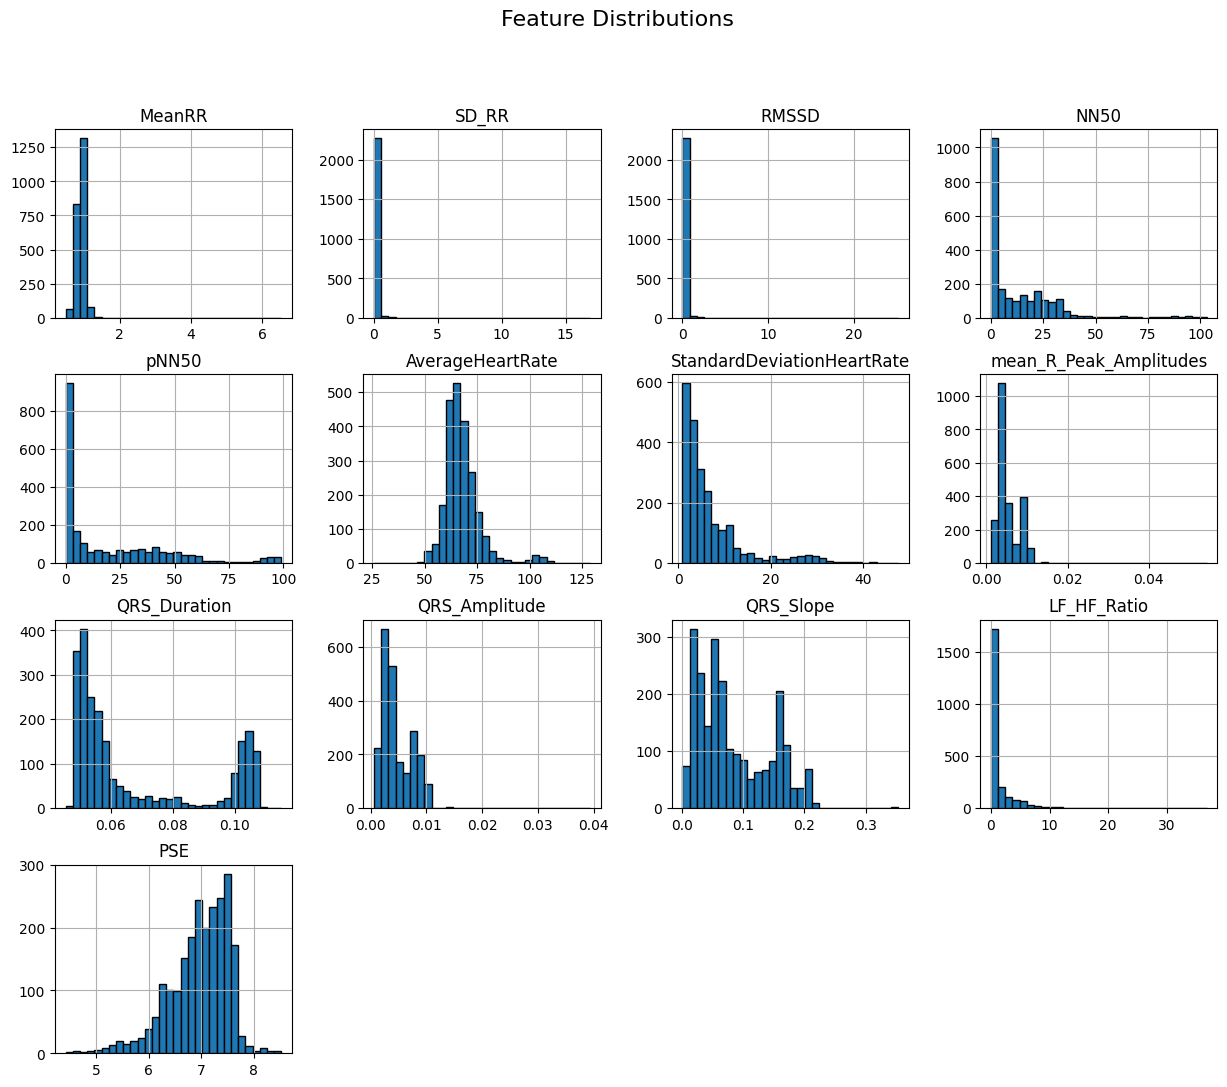

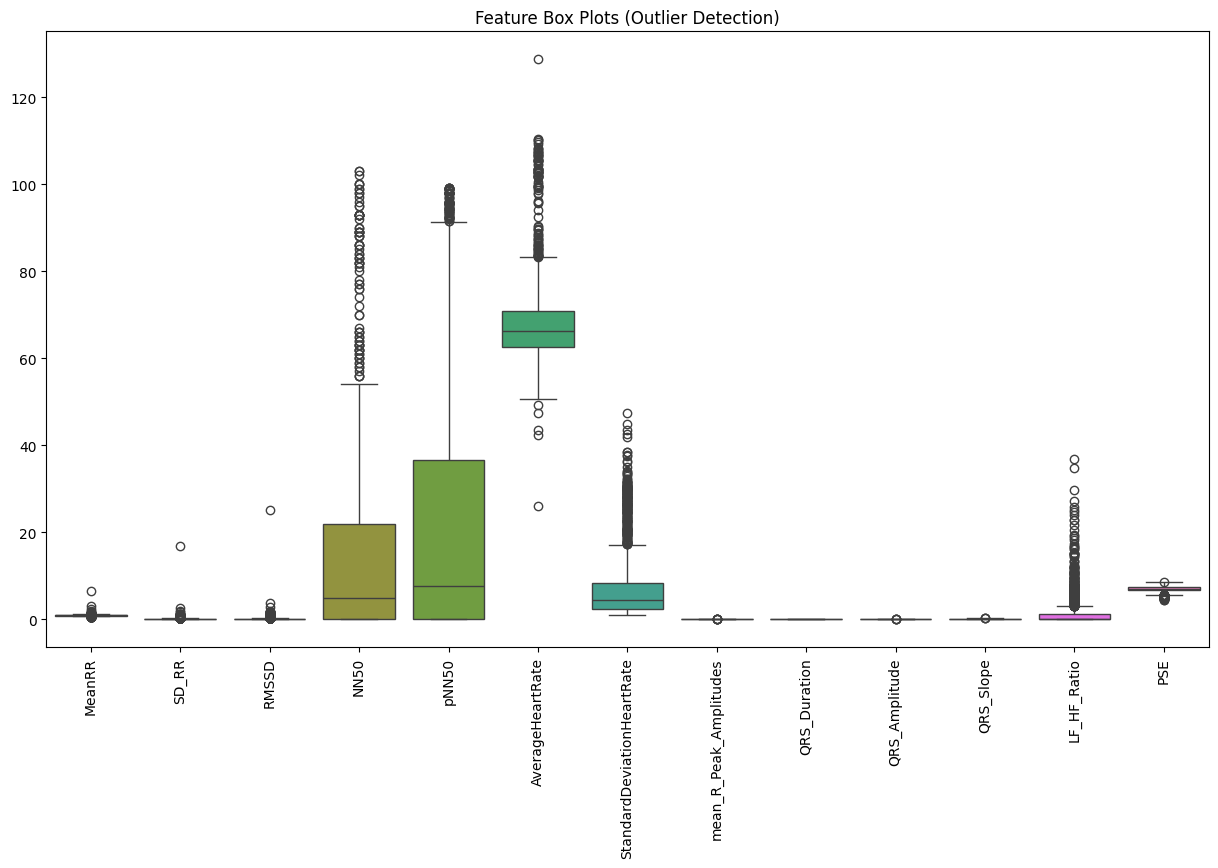

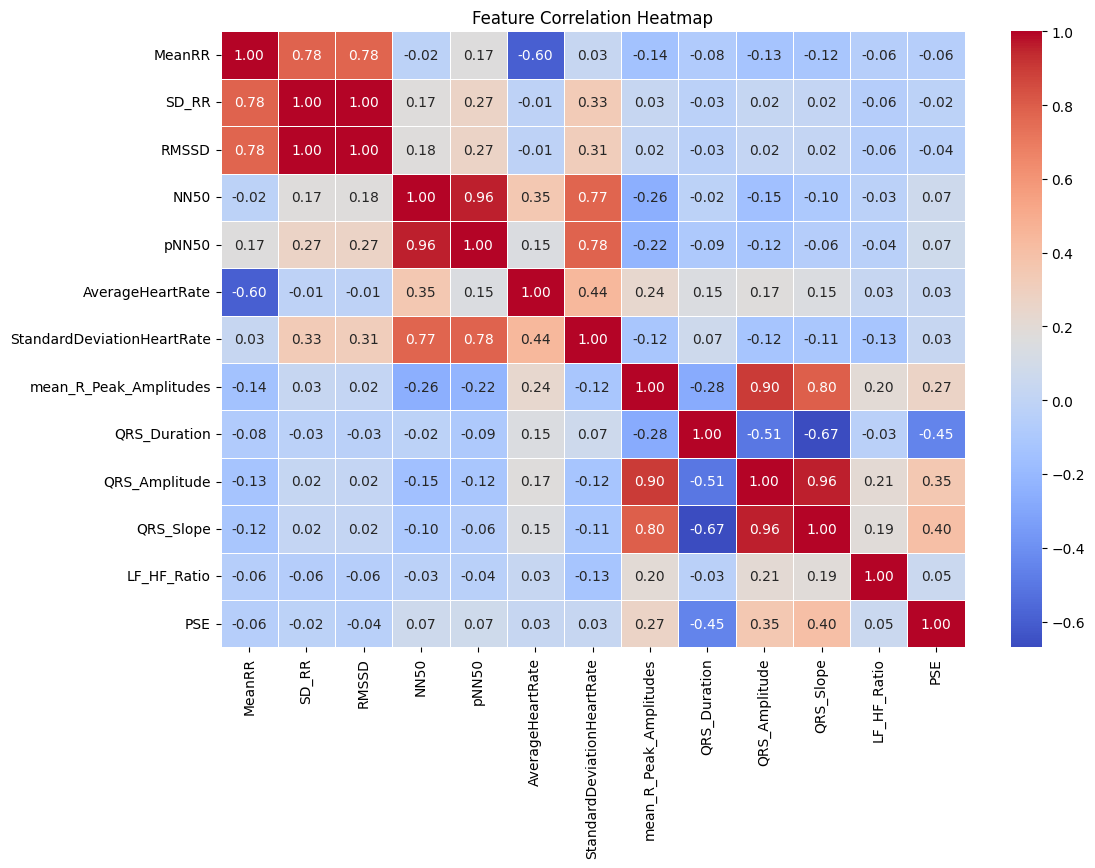

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

summary_stats = features_df.describe()
feature_cols = features_df.select_dtypes(include=[float, int]).columns

#  Summary Statistics
print("Feature Summary Statistics:\n")
print(features_df[feature_cols].describe())

# Feature Distribution Histograms
plt.figure(figsize=(15, 12))
features_df[feature_cols].hist(bins=30, edgecolor="black", figsize=(15, 12))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# Box Plots for Outlier Detection
plt.figure(figsize=(15, 8))
sns.boxplot(data=features_df[feature_cols])
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title("Feature Box Plots (Outlier Detection)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(features_df[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()